In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "Data"

print(f"Using device: {device}")
print(f"Dataset folder exists: {DATA_DIR.exists()}")

Using device: cpu
Dataset folder exists: True


In [3]:
scan_records = []

for class_name, label in [("Hemorrhagic", 1), ("NORMAL", 0)]:
    class_dir = DATA_DIR / class_name

    for folder in class_dir.rglob("*"):
        if folder.is_dir() and any(folder.glob("*.jpg")):
            scan_records.append(
                {
                    "scan_id": str(folder.relative_to(DATA_DIR)),
                    "class_name": class_name,
                    "label": label,
                    "slice_count": len(list(folder.glob("*.jpg"))),
                }
            )

scans_df = pd.DataFrame(scan_records)

print(f"Total scans found: {len(scans_df)}")
scans_df["class_name"].value_counts()

Total scans found: 45


class_name
NORMAL         27
Hemorrhagic    18
Name: count, dtype: int64

In [4]:
excluded_scan_id = r"NORMAL\N27[N27]"

scans_df_clean = (
    scans_df[scans_df["scan_id"] != excluded_scan_id]
    .copy()
    .reset_index(drop=True)
)

print(f"Scans used for Custom CNN: {len(scans_df_clean)}")
scans_df_clean["class_name"].value_counts()

Scans used for Custom CNN: 44


class_name
NORMAL         26
Hemorrhagic    18
Name: count, dtype: int64

In [5]:
train_val_scans, test_scans = train_test_split(
    scans_df_clean,
    test_size=0.20,
    stratify=scans_df_clean["label"],
    random_state=SEED,
)

train_scans, val_scans = train_test_split(
    train_val_scans,
    test_size=0.1875,
    stratify=train_val_scans["label"],
    random_state=SEED,
)

In [7]:
def build_image_dataframe(scan_dataframe):
    records = []

    for _, scan in scan_dataframe.iterrows():
        scan_folder = DATA_DIR / scan["scan_id"]

        for image_path in scan_folder.glob("*.jpg"):
            records.append(
                {
                    "image_path": image_path,
                    "scan_id": scan["scan_id"],
                    "class_name": scan["class_name"],
                    "label": scan["label"],
                }
            )

    return pd.DataFrame(records)


train_images = build_image_dataframe(train_scans)
val_images = build_image_dataframe(val_scans)
test_images = build_image_dataframe(test_scans)

print(len(train_images), len(val_images), len(test_images))
print(train_images["class_name"].value_counts())
print(val_images["class_name"].value_counts())
print(test_images["class_name"].value_counts())

4203 927 1529
class_name
NORMAL         2444
Hemorrhagic    1759
Name: count, dtype: int64
class_name
NORMAL         528
Hemorrhagic    399
Name: count, dtype: int64
class_name
NORMAL         997
Hemorrhagic    532
Name: count, dtype: int64


In [8]:
IMAGE_SIZE = 224

cnn_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

In [9]:
class CTImageDataset(Dataset):
    def __init__(self, images_dataframe, transform=None):
        self.images_dataframe = images_dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.images_dataframe)

    def __getitem__(self, index):
        row = self.images_dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")

            if self.transform:
                image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label

In [10]:
train_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomAffine(
            degrees=10,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ]
)

eval_transform = cnn_transform

In [11]:
train_dataset = CTImageDataset(
    train_images,
    transform=train_transform,
)

val_dataset = CTImageDataset(
    val_images,
    transform=eval_transform,
)

test_dataset = CTImageDataset(
    test_images,
    transform=eval_transform,
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

4203 927 1529


In [12]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [13]:
batch_images, batch_labels = next(iter(train_loader))

print("Image batch shape:", batch_images.shape)
print("Label batch shape:", batch_labels.shape)
print("Labels in batch:", torch.bincount(batch_labels))

Image batch shape: torch.Size([16, 1, 224, 224])
Label batch shape: torch.Size([16])
Labels in batch: tensor([10,  6])


In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [15]:
model = SimpleCNN().to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(model)
print(f"\nTotal trainable parameters: {total_parameters:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=6

In [16]:
class_counts = train_images["label"].value_counts().sort_index()

class_weights = len(train_images) / (
    len(class_counts) * class_counts.values
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

print("Class weights:", class_weights)

Class weights: tensor([0.8599, 1.1947])


In [17]:
EPOCHS = 10

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / "custom_cnn_best.pt"

best_val_auc = -float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
}

In [18]:
def evaluate(model, data_loader):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    average_loss = total_loss / len(data_loader.dataset)
    auc = roc_auc_score(all_labels, all_probabilities)

    return average_loss, auc

In [19]:
def train_one_epoch(model, data_loader):
    model.train()

    total_loss = 0.0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(data_loader.dataset)

In [20]:
class_names = ["NORMAL", "Hemorrhagic"]

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_auc = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f} | "
        f"Validation AUC: {val_auc:.4f}"
    )

    if val_auc > best_val_auc:
        best_val_auc = val_auc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "class_names": class_names,
                "image_size": IMAGE_SIZE,
                "best_val_auc": best_val_auc,
                "history": history,
            },
            CHECKPOINT_PATH,
        )

        print(f"  Best model saved to: {CHECKPOINT_PATH}")

Epoch 1/10 | Train loss: 0.6842 | Validation loss: 0.7506 | Validation AUC: 0.6060
  Best model saved to: e:\vscode\Vision model practice\models\custom_cnn_best.pt
Epoch 2/10 | Train loss: 0.6498 | Validation loss: 1.3165 | Validation AUC: 0.6836
  Best model saved to: e:\vscode\Vision model practice\models\custom_cnn_best.pt
Epoch 3/10 | Train loss: 0.6054 | Validation loss: 1.8502 | Validation AUC: 0.3530
Epoch 4/10 | Train loss: 0.5754 | Validation loss: 1.3261 | Validation AUC: 0.6095
Epoch 5/10 | Train loss: 0.5491 | Validation loss: 1.7819 | Validation AUC: 0.5327
Epoch 6/10 | Train loss: 0.5163 | Validation loss: 1.9478 | Validation AUC: 0.6298
Epoch 7/10 | Train loss: 0.4841 | Validation loss: 2.5261 | Validation AUC: 0.6453
Epoch 8/10 | Train loss: 0.4681 | Validation loss: 2.6947 | Validation AUC: 0.6338
Epoch 9/10 | Train loss: 0.4314 | Validation loss: 1.8217 | Validation AUC: 0.4484
Epoch 10/10 | Train loss: 0.4287 | Validation loss: 2.8405 | Validation AUC: 0.6386


In [21]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded best model from epoch: {checkpoint['epoch']}")
print(f"Best validation AUC: {checkpoint['best_val_auc']:.4f}")

Loaded best model from epoch: 2
Best validation AUC: 0.6836


In [22]:
test_loss, test_auc = evaluate(model, test_loader)

print(f"Test loss: {test_loss:.4f}")
print(f"Test ROC-AUC: {test_auc:.4f}")

Test loss: 1.1205
Test ROC-AUC: 0.5571


In [23]:
test_labels = []
test_probabilities = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_labels = np.array(test_labels)
test_probabilities = np.array(test_probabilities)
test_predictions = (test_probabilities >= 0.5).astype(int)

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

tn, fp, fn, tp = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
).ravel()

test_metrics = pd.Series(
    {
        "Loss": test_loss,
        "Accuracy": accuracy_score(test_labels, test_predictions),
        "Balanced accuracy": balanced_accuracy_score(
            test_labels, test_predictions
        ),
        "Precision": precision_score(test_labels, test_predictions),
        "Recall / Sensitivity": recall_score(test_labels, test_predictions),
        "Specificity": tn / (tn + fp),
        "F1 score": f1_score(test_labels, test_predictions),
        "ROC-AUC": roc_auc_score(test_labels, test_probabilities),
        "PR-AUC": average_precision_score(
            test_labels, test_probabilities
        ),
    }
)

test_metrics.round(4)

C:\Users\prana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Loss                    1.1205
Accuracy                0.6521
Balanced accuracy       0.5000
Precision               0.0000
Recall / Sensitivity    0.0000
Specificity             1.0000
F1 score                0.0000
ROC-AUC                 0.5571
PR-AUC                  0.4881
dtype: float64

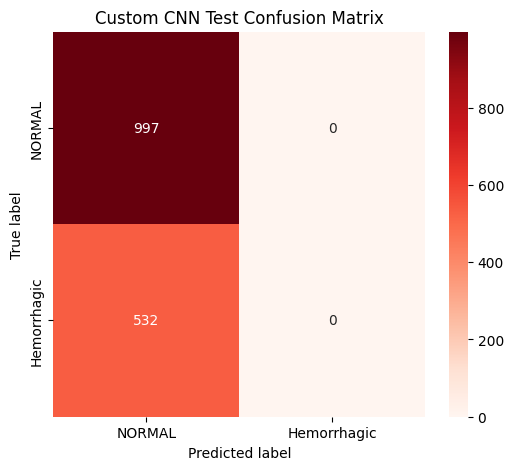

In [25]:
confusion_matrix_values = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Custom CNN Test Confusion Matrix")
plt.show()

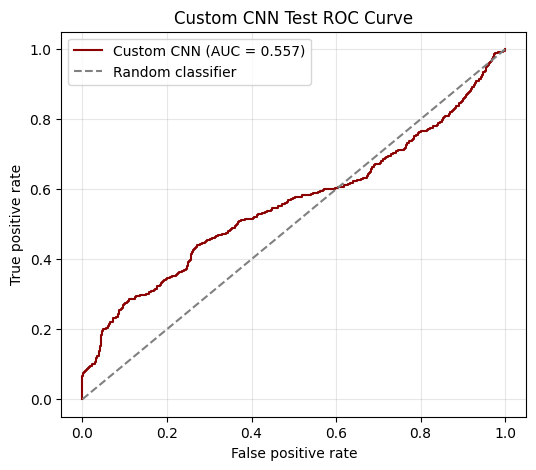

In [26]:
from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, _ = roc_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    color="darkred",
    label=f"Custom CNN (AUC = {test_auc:.3f})",
)

plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Custom CNN Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

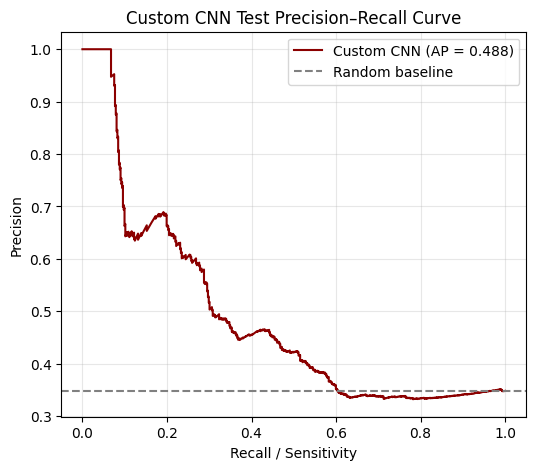

In [27]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    test_labels,
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    recall_curve,
    precision_curve,
    color="darkred",
    label=f"Custom CNN (AP = {test_metrics['PR-AUC']:.3f})",
)

plt.axhline(
    test_labels.mean(),
    linestyle="--",
    color="gray",
    label="Random baseline",
)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Custom CNN Test Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

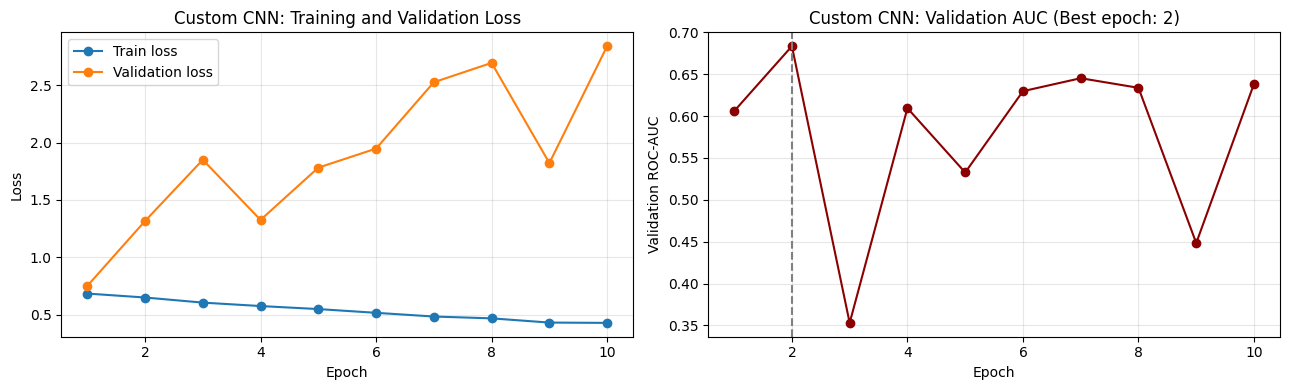

In [28]:
epochs = range(1, len(history["train_loss"]) + 1)
best_epoch = np.argmax(history["val_auc"]) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Custom CNN: Training and Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["val_auc"], marker="o", color="darkred")
axes[1].axvline(best_epoch, linestyle="--", color="gray")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].set_title(f"Custom CNN: Validation AUC (Best epoch: {best_epoch})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()